In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
from scipy.stats import norm
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from Database.queries import *
from Features.features import *
from Strategies.strategies import *
from BackTester.backtester import BackTester

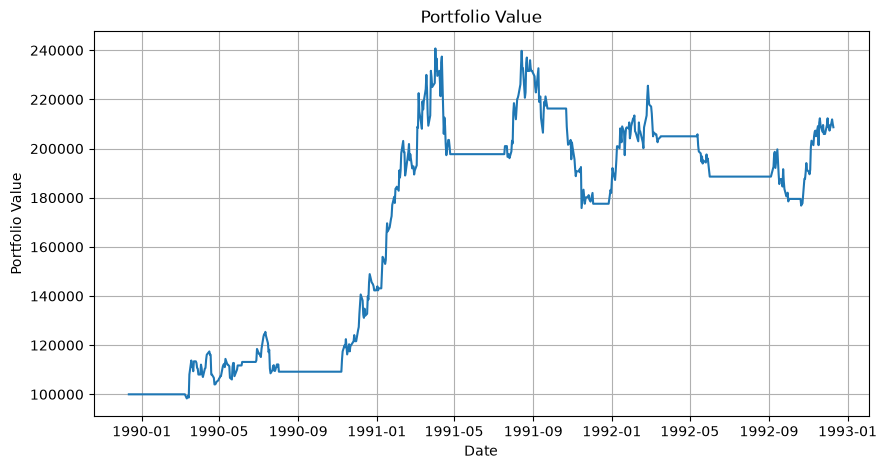

In [2]:
assets = ['AAPL', 'TSLA', 'GOOGL']
window = 252
n = 2
start = "1989-12-12"
end = "1992-12-10"
short_window = 10
long_window = 50

# prices
prices_open = get_prices(assets=assets, field='open', pivot=True)
prices_close = get_prices(assets=assets, field='close', pivot=True)

# strategy
weights1 = momentum_strategy(prices_close, window=window, n=n)
weights2 = MA_strategy(prices_close, long_window, short_window)
weights3 = cash_only(prices_close)

# Backtest
bt = BackTester(prices_open, prices_close)
results = bt.run(weights2, start=start, end=end)
bt.plot_portfolio_value()

In [3]:
results['Weights'].value_counts()

AAPL  GOOGL  TSLA
1.0   0.0    0.0     389
0.0   0.0    0.0     370
Name: count, dtype: int64

In [4]:
results['Weights']

ticker,AAPL,GOOGL,TSLA
date,,,
1989-12-12,0.0,0.0,0.0
1989-12-13,0.0,0.0,0.0
1989-12-14,0.0,0.0,0.0
1989-12-15,0.0,0.0,0.0
1989-12-18,0.0,0.0,0.0
...,...,...,...
1992-12-04,1.0,0.0,0.0
1992-12-07,1.0,0.0,0.0
1992-12-08,1.0,0.0,0.0


In [5]:
cash = results['Cash']
cash#.iloc[100:150]

date
1989-12-11    100000.000000
1989-12-12    100000.000000
1989-12-13    100000.000000
1989-12-14    100000.000000
1989-12-15    100000.000000
                  ...      
1992-12-04         0.364638
1992-12-07         0.364638
1992-12-08         0.364638
1992-12-09         0.364638
1992-12-10         0.364638
Length: 760, dtype: float64

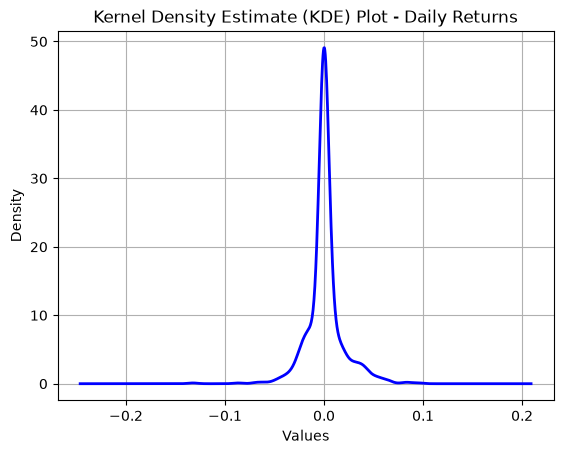

In [6]:
returns = results['Daily Returns']
returns.plot.density(color='blue', linewidth=2)
plt.title("Kernel Density Estimate (KDE) Plot - Daily Returns")
plt.xlabel("Values")
plt.ylabel("Density")
plt.grid(True)
plt.show()

In [7]:
results['Cumulative Daily Returns'], results['Metrics']['CAGR'], results['Metrics']['Sharpe']

(1.0867878789958358, 0.27838927352298537, 0.9860915618826117)

In [8]:
drawdown = results['Metrics']['Drawdown']
max_drawdown = results['Metrics']['Max Drawdown']
drawdown, max_drawdown

(date
 1989-12-12    0.000000
 1989-12-13    0.000000
 1989-12-14    0.000000
 1989-12-15    0.000000
 1989-12-18    0.000000
                 ...   
 1992-12-04   -0.138898
 1992-12-07   -0.125651
 1992-12-08   -0.119974
 1992-12-09   -0.127544
 1992-12-10   -0.133221
 Length: 759, dtype: float64,
 -0.2698011111533319)

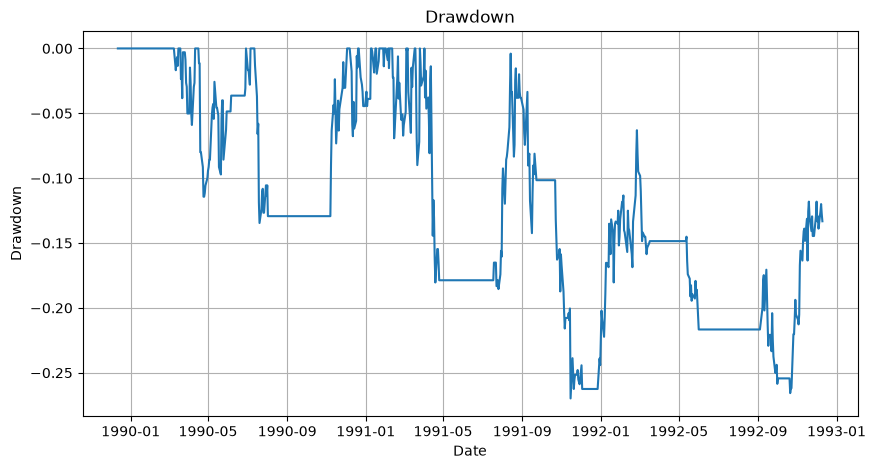

In [9]:
drawdown.plot(figsize=(10, 5))
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

In [10]:
results['Metrics']['Volatility']

0.2909734432917915

In [11]:
results['Orders']

,date,ticker,side,shares,price,cash after transaction
0,1990-03-12,AAPL,BUY,300671.0,0.332589,0.132642
1,1990-05-30,AAPL,SELL,300671.0,0.371652,111745.113269
2,1990-06-06,AAPL,BUY,320909.0,0.348214,0.106595
3,1990-06-07,AAPL,SELL,320909.0,0.352679,113177.976364
4,1990-06-28,AAPL,BUY,296513.0,0.381696,0.154529
5,1990-08-02,AAPL,SELL,296513.0,0.368304,109207.082693
6,1990-11-08,AAPL,BUY,370642.0,0.294643,0.006450
7,1991-04-25,AAPL,SELL,370642.0,0.533482,197730.847503
8,1991-07-19,AAPL,BUY,489410.0,0.404018,0.390943
9,1991-09-24,AAPL,SELL,489410.0,0.441964,216301.992410
